<a href="https://colab.research.google.com/github/somendrew/LangGraph_tutorial/blob/main/3_State_%E2%80%94_What_It_Is_and_How_It_Flows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# State

### 1. What is it?
State is the shared data object that travels through every node in your graph. Each node can read from it and write updates to it. It's the single source of truth for everything happening in your app at any moment.

### 2. Why does it matter?
Without state, your nodes would be isolated — they couldn't share information. State is what lets node 2 know what node 1 discovered, and node 3 know what node 2 decided. It's the memory of the current run.

### 3. The Analogy
Think of state like a patient's chart in a hospital:

* The patient carries it from room to room
* Each doctor (node) reads what previous doctors wrote
* Each doctor adds their own notes before passing it on
* No doctor needs to ask "what happened before?" — it's all in the chart


### 4. Visual: How State Flows and Mutates

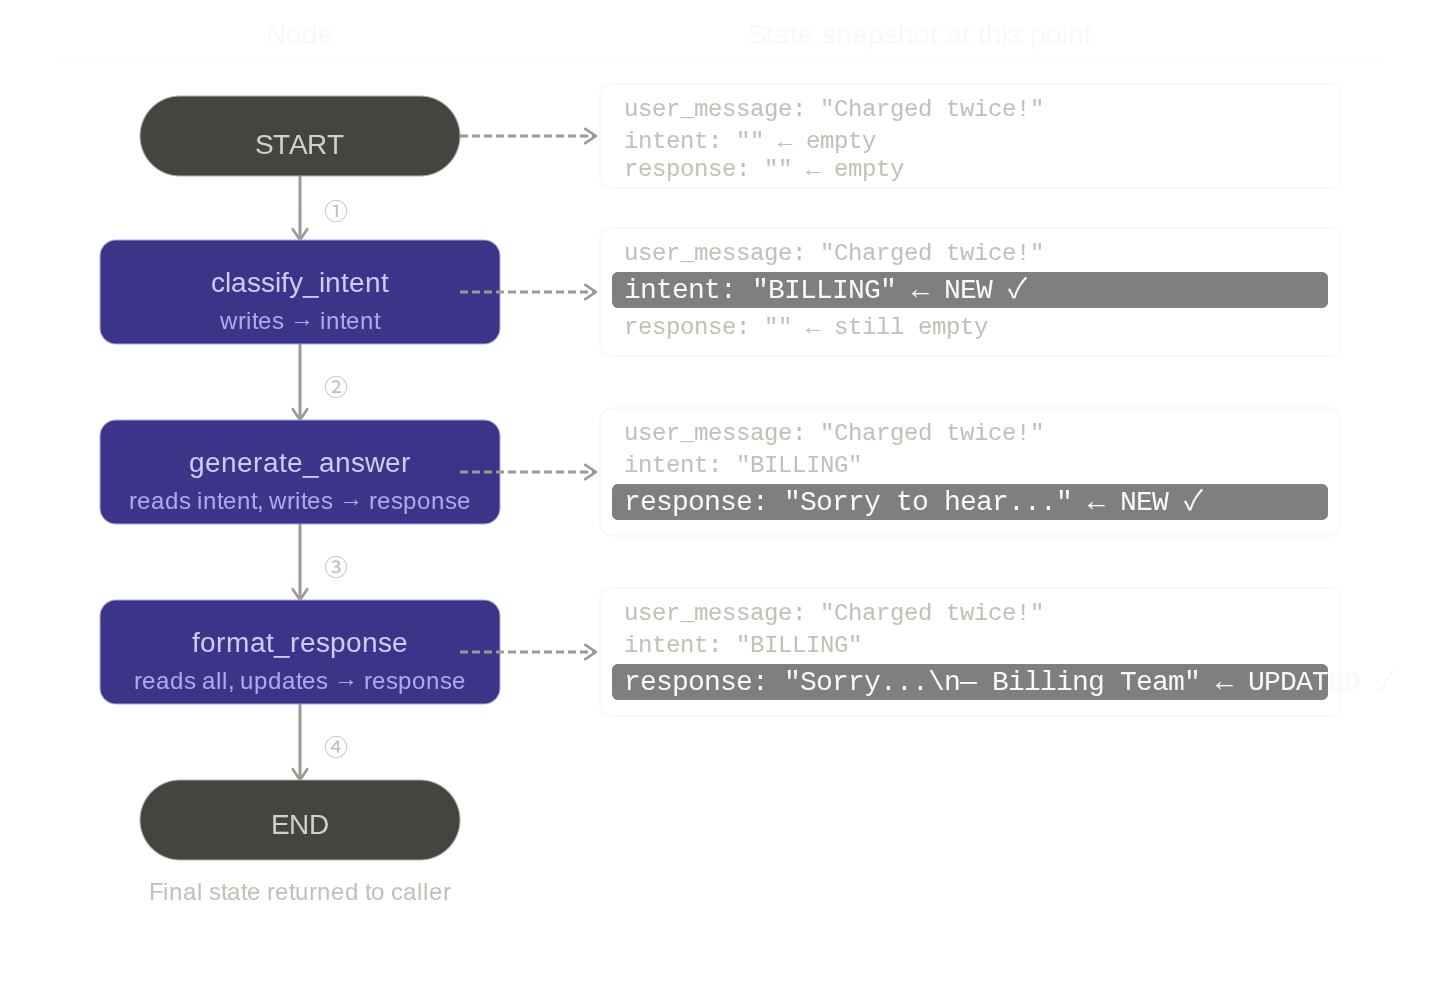

## 5. Three ways to define State

#### Pattern A -- Basic TypedDict

In [1]:
# Simple, clean — good for most use cases
# Each node REPLACES the field it returns
from typing import TypedDict

class SupportState(TypedDict):
    user_message: str
    intent: str
    response: str

# If generate_answer returns {"response": "Hello"},
# it REPLACES whatever was in response before.

#### Pattern B -- Annotated fields with Reducers (recommended)

In [2]:
# ============================================================
# NEW CONCEPT: Reducers
# A reducer tells LangGraph HOW to merge a new value
# into the existing state, instead of just replacing it.
# ============================================================

from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages  # a built-in reducer

class ChatState(TypedDict):
    # Plain field — new value REPLACES old value
    user_message: str

    # Annotated field with reducer — new value is APPENDED
    # add_messages is LangGraph's built-in chat history reducer
    messages: Annotated[list, add_messages]  # NEW: reducer annotation


### Pattern C -- Write your own reducer

In [3]:
# You can write any merge logic you want
def append_to_list(existing: list, new: list) -> list:
    """Instead of replacing, append new items to existing list."""
    return existing + new

class ResearchState(TypedDict):
    query: str
    # Each node can ADD findings without wiping previous ones
    findings: Annotated[list, append_to_list]  # NEW: custom reducer


## 6. Adding  Chat history to BOT

### customer_support_bot.py — Proper State with Reducers

In [1]:
!pip install -q langchain_openai langgraph typing langchain_core

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 23.7 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
api_key = userdata.get('api_key')

In [7]:
# ============================================================
# customer_support_bot.py — Topic 3: Proper State with Reducers
# Changes from Topic 2 are marked with # NEW
# ============================================================

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages      # NEW: built-in reducer
from langchain_core.messages import HumanMessage, AIMessage  # NEW: message types
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated               # NEW: Annotated

llm = ChatOpenAI(model="gpt-4o-mini",api_key = api_key)

# ── 1. Upgraded State with a reducer ─────────────────────
class SupportState(TypedDict):
    user_message: str
    intent:       str
    response:     str
    # NEW: messages is a list that ACCUMULATES — it never gets wiped.
    # add_messages is a reducer: it appends new messages to the list.
    # This is how LangGraph tracks conversation history.
    messages: Annotated[list, add_messages]

# ── 2. Nodes — same logic, now also updating messages ─────

def classify_intent(state: SupportState) -> dict:
    """Node 1: classify the user's intent."""
    prompt = f"""Classify this message into one word: BILLING, TECHNICAL, or GENERAL.
Message: {state['user_message']}
Reply with just the one word."""

    result = llm.invoke(prompt)
    intent = result.content.strip()
    print(f"[Node 1] Intent detected: {intent}")
    return {"intent": intent}


def generate_answer(state: SupportState) -> dict:
    """Node 2: generate a reply using full message history."""

    # NEW: We now pass the entire message history to the LLM
    # This gives the LLM full context of the conversation
    history = state["messages"]   # all prior messages

    # Add a system instruction at the start
    system = f"You are a helpful support agent. Message type: {state['intent']}"

    result = llm.invoke([
        {"role": "system",  "content": system},
        *[{"role": m.type, "content": m.content} for m in history],
    ])

    print(f"[Node 2] Generated answer")

    # NEW: Return BOTH the response text AND append to message history
    # add_messages reducer will APPEND this — not replace the list
    return {
        "response": result.content,
        "messages": [AIMessage(content=result.content)],  # appended, not replaced
    }


def format_response(state: SupportState) -> dict:
    """Node 3: add a sign-off to the response."""
    sign_off = {
        "BILLING":   "— Billing Team",
        "TECHNICAL": "— Tech Support",
        "GENERAL":   "— Support Team",
    }.get(state["intent"], "— Support Team")

    formatted = f"{state['response']}\n\n{sign_off}"
    print(f"[Node 3] Formatted with sign-off")
    return {"response": formatted}


# ── 3. Build graph (identical structure to Topic 2) ───────
builder = StateGraph(SupportState)

builder.add_node("classify_intent", classify_intent)
builder.add_node("generate_answer", generate_answer)
builder.add_node("format_response", format_response)

builder.add_edge(START,             "classify_intent")
builder.add_edge("classify_intent", "generate_answer")
builder.add_edge("generate_answer", "format_response")
builder.add_edge("format_response", END)

app = builder.compile()

# ── 4. Run it — now with message history ─────────────────
initial_state = {
    "user_message": "I was charged twice for my subscription!",
    "intent":       "",
    "response":     "",
    # NEW: seed the messages list with the user's first message
    "messages":     [HumanMessage(content="I was charged twice for my subscription!")],
}

result = app.invoke(initial_state)

print("\n── Final Response ──")
print(result["response"])

print("\n── Message History ──")
for msg in result["messages"]:
    role = "User" if isinstance(msg, HumanMessage) else "Bot"
    print(f"[{role}]: {msg.content[:60]}...")

[Node 1] Intent detected: BILLING
[Node 2] Generated answer
[Node 3] Formatted with sign-off

── Final Response ──
I'm sorry to hear about the duplicate charge. To assist you better, could you please provide me with the following details:

1. The email address associated with your subscription.
2. The date of the charges.
3. The amount charged.

With this information, I can help you resolve the issue.

— Billing Team

── Message History ──
[User]: I was charged twice for my subscription!...
[Bot]: I'm sorry to hear about the duplicate charge. To assist you ...


## Key Takeaways

State      = the shared data object every node reads and writes</br>
TypedDict  = the type definition (schema) for your state</br>
Reducer    = a function that controls HOW a field gets updated</br>
             └─ default: REPLACE (new value overwrites old)</br>
             └─ add_messages: APPEND (new messages join the list)</br>

Nodes return a PARTIAL dict — only the fields they changed.</br>
LangGraph MERGES that partial dict back into the full state.</br>